Папка с данными найдена: c:\Users\Admin\Documents\GitHub\Food_delivery_analytics_report\data\raw
Все основные файлы загружены!
Типы данных преобразованы.


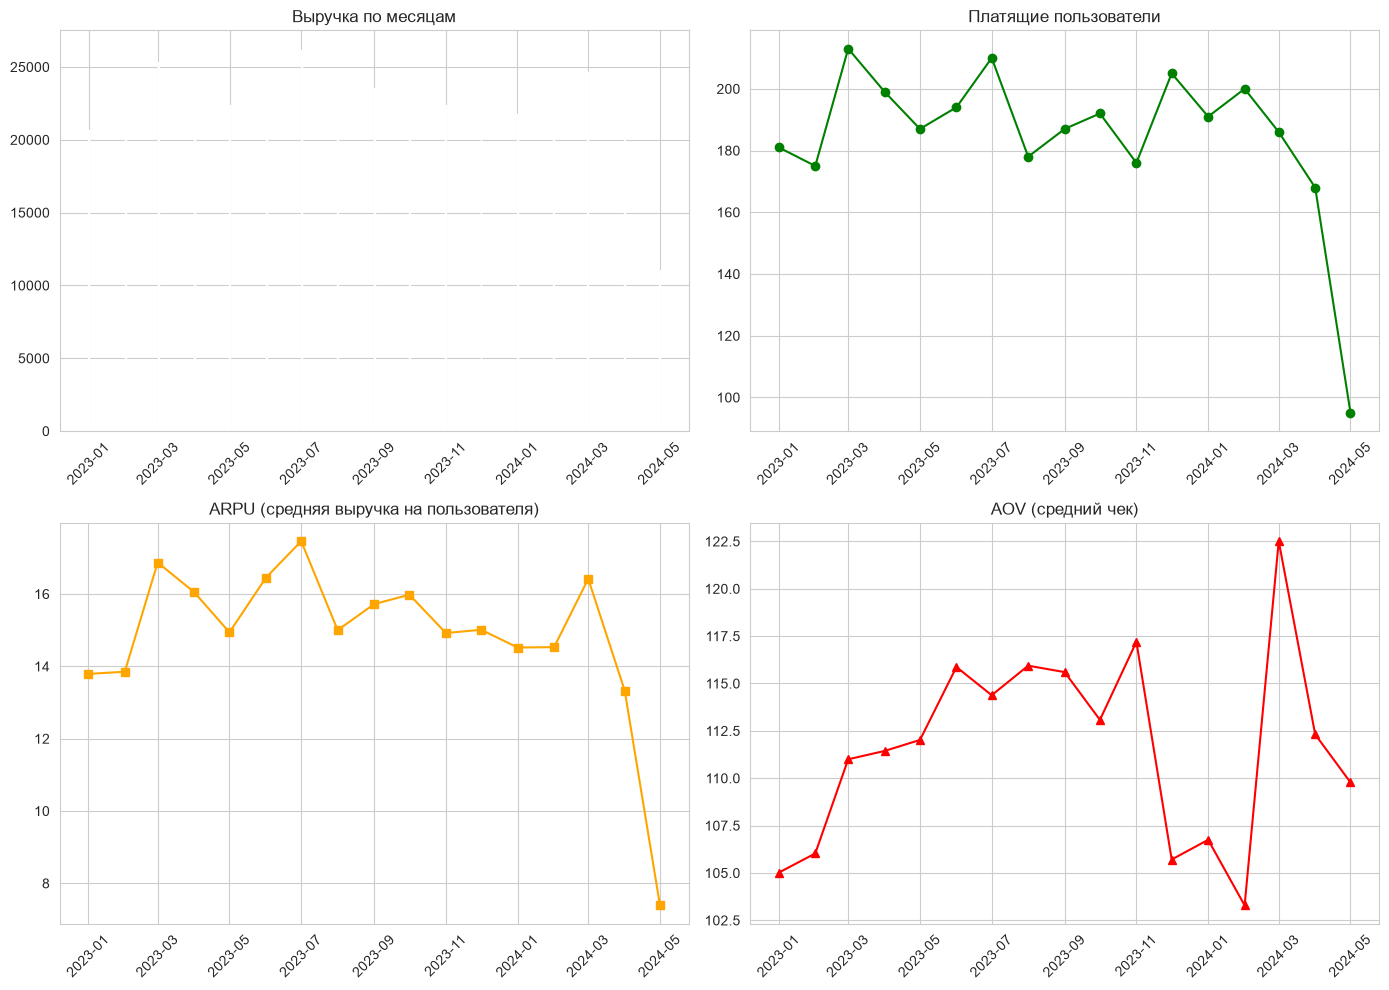

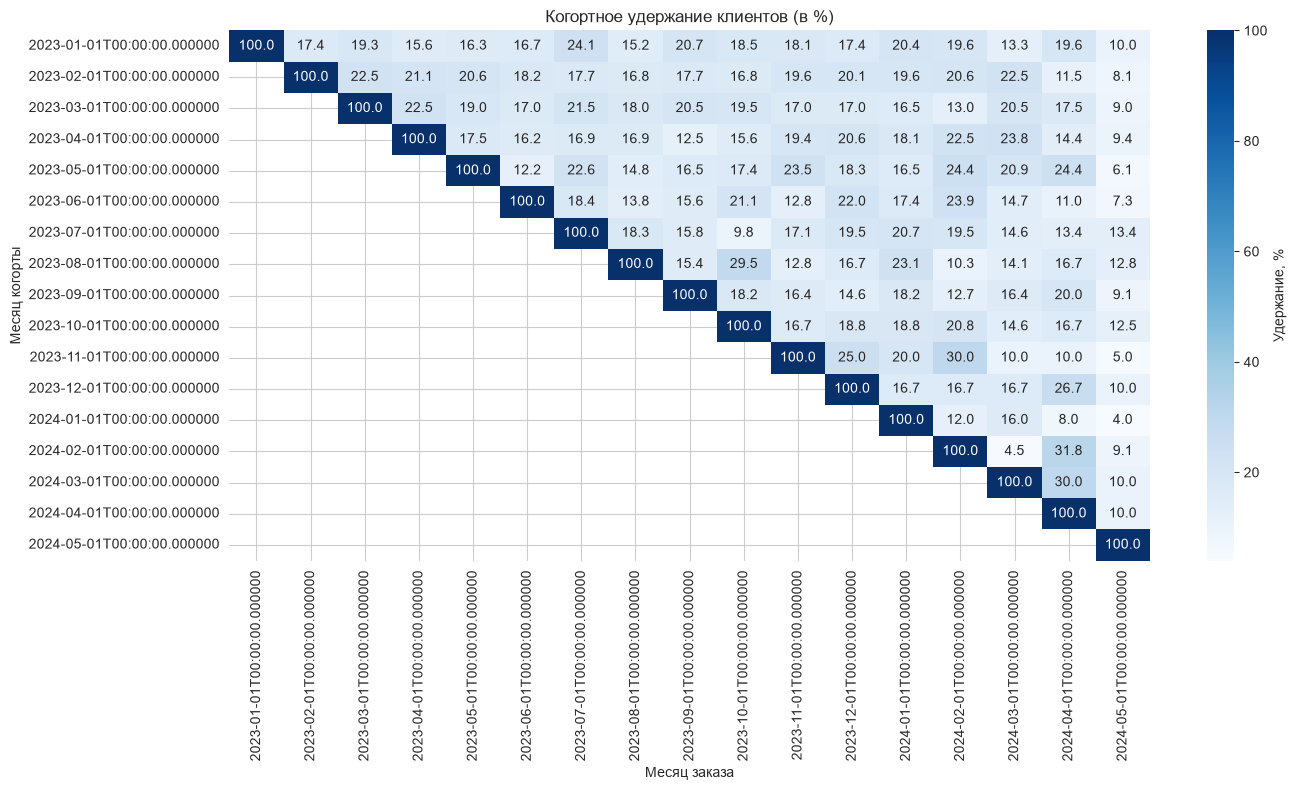


=== Распределение по RFM-сегментам ===
segment
Others                 463
At Risk                437
Champions              239
Potential Loyalists    190
Hibernating             24
Name: count, dtype: int64


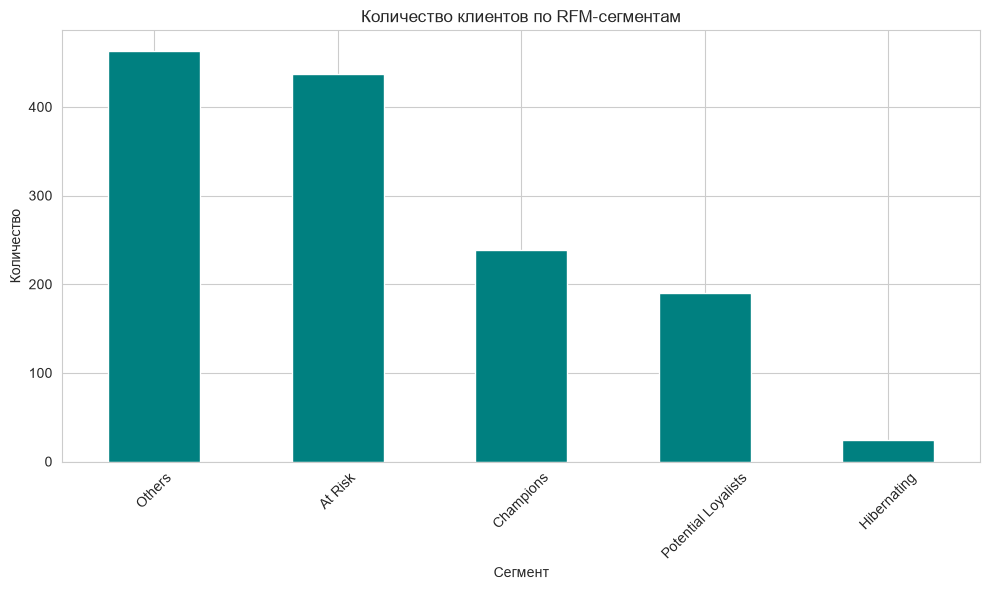

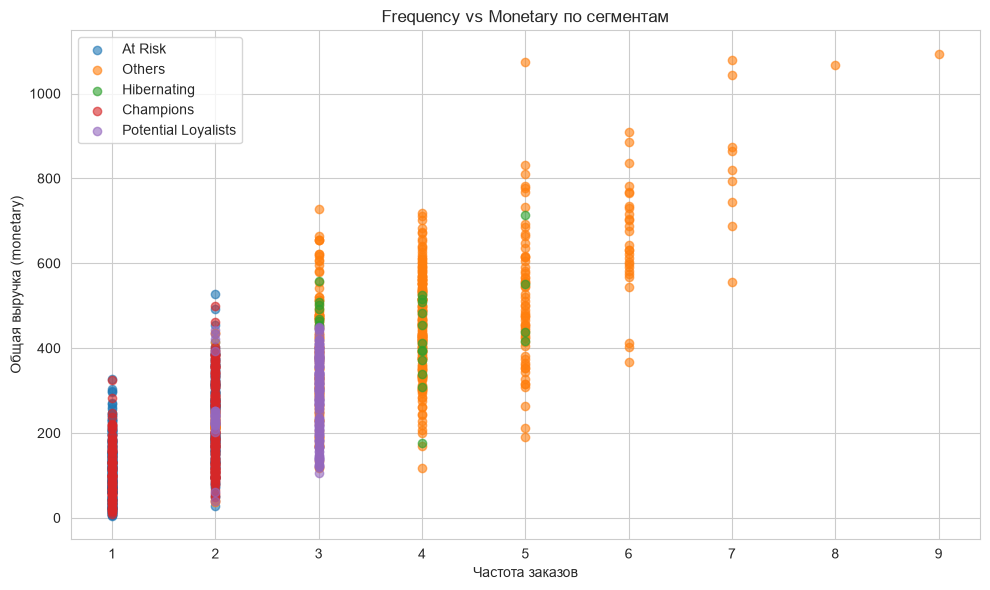

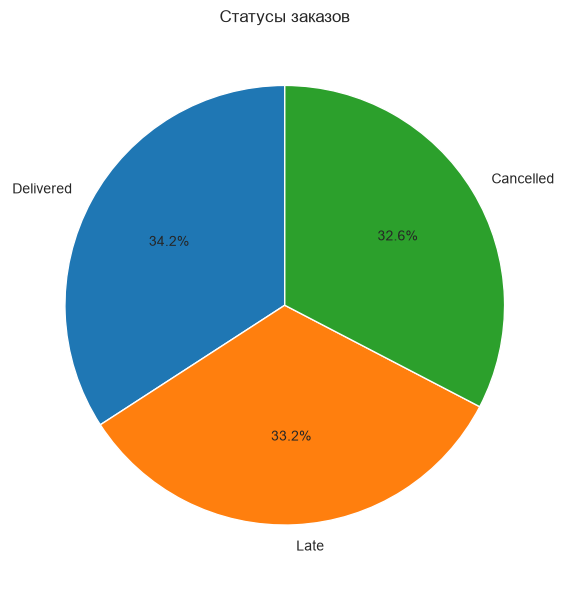

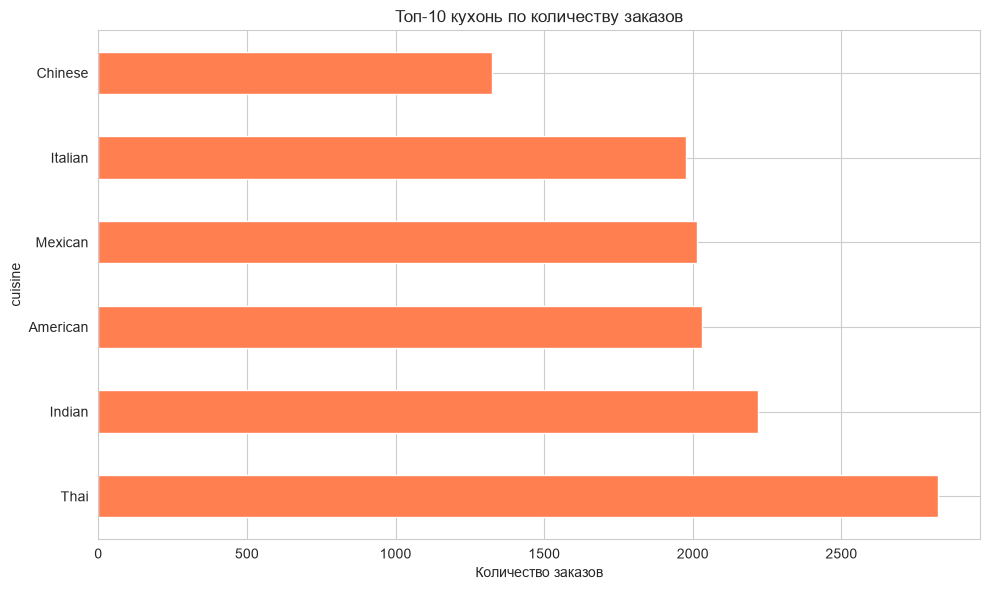

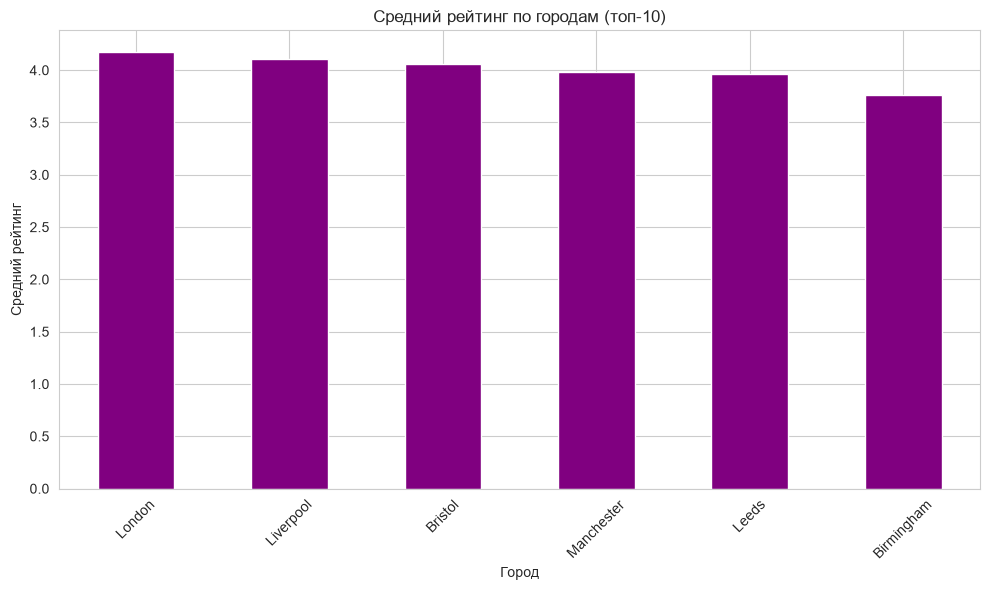

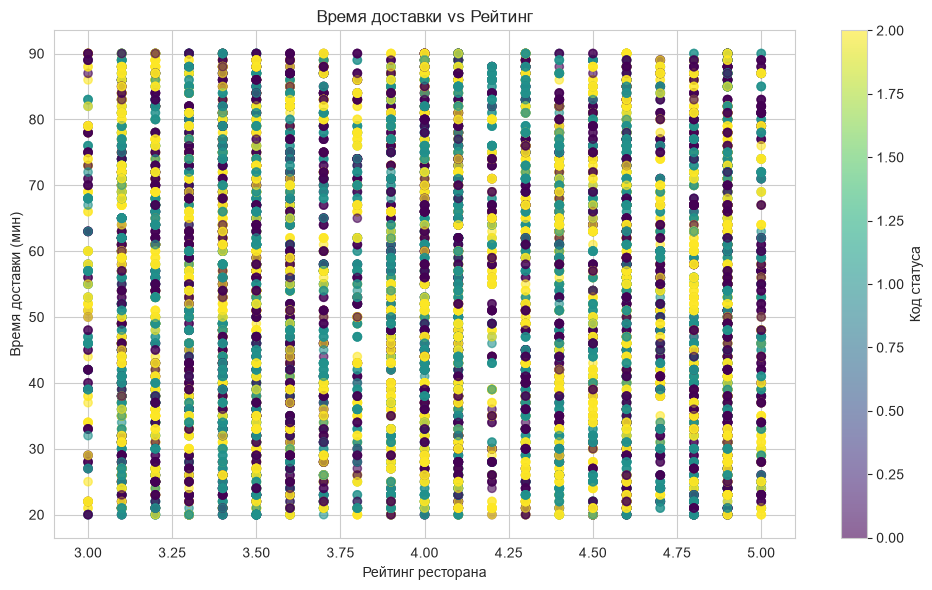

interactive(children=(DatePicker(value=Timestamp('2023-01-01 00:00:00'), description='С', step=1), DatePicker(…


Экспорт завершён в папку data/processed.

Анализ успешно выполнен!


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# --- Автоматический поиск папки data/raw (на 2 уровня выше!) ---
def find_raw_dir():
    current_dir = Path.cwd()
    possible_dirs = [
        current_dir.parent.parent / "data" / "raw",  # Из notebooks/cod
        current_dir.parent / "data" / "raw",         # Из notebooks
        current_dir / "data" / "raw"                 # Если случайно положить в корень
    ]
    for path in possible_dirs:
        if path.exists():
            return path
    return None

RAW_DIR = find_raw_dir()
if RAW_DIR is None:
    print(f"Не найдена папка data/raw! Текущая директория: {Path.cwd()}")
    print("Проверьте, лежат ли ваши .csv файлы в data/raw.")
else:
    print(f"Папка с данными найдена: {RAW_DIR}")

# Создаем папку для сохранения результатов
PROCESSED_DIR = RAW_DIR.parent / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

# --- Попытка импорта seaborn ---
try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_style('whitegrid')
except ImportError:
    HAS_SEABORN = False
    print("Seaborn не установлен.")

# --- Проверка ipywidgets ---
try:
    from ipywidgets import interact, widgets, VBox, HBox, Output
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

# --- Загрузка данных ---
files = {
    'cohort': RAW_DIR / 'v_cohort_retention.csv',
    'rfm': RAW_DIR / 'v_customer_rfm.csv',
    'fin': RAW_DIR / 'v_financial_metrics.csv',
    'orders': RAW_DIR / 'v_full_orders.csv'
}

try:
    growth = pd.read_csv(RAW_DIR / 'v_growth_metrics.csv')
except:
    growth = None

try:
    cohort = pd.read_csv(files['cohort'])
    rfm = pd.read_csv(files['rfm'])
    fin = pd.read_csv(files['fin'])
    orders = pd.read_csv(files['orders'])
    print("Все основные файлы загружены!")
except FileNotFoundError as e:
    print(f"Ошибка загрузки: {e}")
    raise

# --- Предобработка ---
cohort['cohort_month'] = pd.to_datetime(cohort['cohort_month'])
cohort['order_month'] = pd.to_datetime(cohort['order_month'])
fin['month'] = pd.to_datetime(fin['month'])
orders['order_time'] = pd.to_datetime(orders['order_time'])
orders['delivery_time'] = pd.to_datetime(orders['delivery_time'])
orders['signup_date'] = pd.to_datetime(orders['signup_date'])

orders['delivery_min'] = (orders['delivery_time'] - orders['order_time']).dt.total_seconds() / 60
orders['order_month'] = orders['order_time'].dt.to_period('M').dt.to_timestamp()

print("Типы данных преобразованы.")

# =============================================================================
# 3. Финансовые метрики (Только показ)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].bar(fin['month'], fin['revenue'], color='skyblue')
axes[0].set_title('Выручка по месяцам')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(fin['month'], fin['paying_users'], marker='o', color='green')
axes[1].set_title('Платящие пользователи')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(fin['month'], fin['arpu'], marker='s', color='orange')
axes[2].set_title('ARPU (средняя выручка на пользователя)')
axes[2].tick_params(axis='x', rotation=45)

axes[3].plot(fin['month'], fin['aov'], marker='^', color='red')
axes[3].set_title('AOV (средний чек)')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. Когортное удержание
# =============================================================================
pivot = cohort.pivot(index='cohort_month', columns='order_month', values='retention_pct')

fig, ax = plt.subplots(figsize=(14, 8))
if HAS_SEABORN:
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Удержание, %'}, ax=ax)
else:
    im = ax.imshow(pivot, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([d.strftime('%Y-%m') for d in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([d.strftime('%Y-%m') for d in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center', 
                        color='white' if val > 50 else 'black')
    plt.colorbar(im, ax=ax, label='Удержание, %')
ax.set_title('Когортное удержание клиентов (в %)')
ax.set_xlabel('Месяц заказа')
ax.set_ylabel('Месяц когорты')
plt.tight_layout()
plt.show()

# =============================================================================
# 5. RFM-сегментация
# =============================================================================
print("\n=== Распределение по RFM-сегментам ===")
seg_counts = rfm['segment'].value_counts()
print(seg_counts)

plt.figure(figsize=(10, 6))
seg_counts.plot(kind='bar', color='teal')
plt.title('Количество клиентов по RFM-сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for seg in rfm['segment'].unique():
    subset = rfm[rfm['segment'] == seg]
    plt.scatter(subset['frequency'], subset['monetary'], label=seg, alpha=0.6)
plt.xlabel('Частота заказов')
plt.ylabel('Общая выручка (monetary)')
plt.title('Frequency vs Monetary по сегментам')
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# 6. Детальный анализ заказов
# =============================================================================
status_counts = orders['status'].value_counts()
plt.figure(figsize=(8, 6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Статусы заказов')
plt.ylabel('')
plt.tight_layout()
plt.show()

top_cuisines = orders['cuisine'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_cuisines.plot(kind='barh', color='coral')
plt.title('Топ-10 кухонь по количеству заказов')
plt.xlabel('Количество заказов')
plt.tight_layout()
plt.show()

city_rating = orders.groupby('city')['rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
city_rating.plot(kind='bar', color='purple')
plt.title('Средний рейтинг по городам (топ-10)')
plt.xlabel('Город')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(orders['rating'], orders['delivery_min'], 
                      c=orders['status'].astype('category').cat.codes, 
                      alpha=0.6, cmap='viridis')
plt.colorbar(scatter, label='Код статуса')
plt.xlabel('Рейтинг ресторана')
plt.ylabel('Время доставки (мин)')
plt.title('Время доставки vs Рейтинг')
plt.tight_layout()
plt.show()

# =============================================================================
# 7. Интерактивный дашборд (если есть ipywidgets)
# =============================================================================
if HAS_WIDGETS:
    date_start = widgets.DatePicker(description='С', value=fin['month'].min())
    date_end = widgets.DatePicker(description='По', value=fin['month'].max())
    segment_dropdown = widgets.Dropdown(
        options=['Все'] + sorted(rfm['segment'].unique()),
        value='Все',
        description='Сегмент:'
    )
    output = Output()

    def update_dashboard(month_start, month_end, segment):
        with output:
            clear_output(wait=True)
            mask_fin = (fin['month'] >= pd.to_datetime(month_start)) & (fin['month'] <= pd.to_datetime(month_end))
            fin_filtered = fin[mask_fin]
            
            if segment != 'Все':
                rfm_filtered = rfm[rfm['segment'] == segment]
            else:
                rfm_filtered = rfm
            
            fig1, ax1 = plt.subplots(figsize=(12, 5))
            ax1.bar(fin_filtered['month'], fin_filtered['revenue'], color='blue', alpha=0.6, label='Выручка')
            ax1.set_xlabel('Месяц')
            ax1.set_ylabel('Выручка', color='blue')
            ax1.tick_params(axis='x', rotation=45)
            ax2 = ax1.twinx()
            ax2.plot(fin_filtered['month'], fin_filtered['arpu'], color='red', marker='o', label='ARPU')
            ax2.set_ylabel('ARPU', color='red')
            plt.title(f'Выручка и ARPU (сегмент: {segment})')
            fig1.legend(loc='upper left')
            plt.tight_layout()
            plt.show()
            
            if segment == 'Все':
                fig2, ax2 = plt.subplots(figsize=(8, 6))
                rfm['segment'].value_counts().plot(kind='bar', ax=ax2, color='teal')
                ax2.set_title('Все клиенты по сегментам')
                ax2.set_xlabel('Сегмент')
                ax2.set_ylabel('Количество')
                plt.tight_layout()
                plt.show()
            else:
                fig2, ax2 = plt.subplots(figsize=(8, 6))
                rfm_filtered['frequency'].hist(bins=10, ax=ax2, color='orange', edgecolor='black')
                ax2.set_title(f'Распределение частоты заказов в сегменте {segment}')
                ax2.set_xlabel('Частота')
                ax2.set_ylabel('Количество клиентов')
                plt.tight_layout()
                plt.show()
            
            fig3, ax3 = plt.subplots(figsize=(10, 6))
            for seg in rfm_filtered['segment'].unique():
                subset = rfm_filtered[rfm_filtered['segment'] == seg]
                ax3.scatter(subset['frequency'], subset['monetary'], label=seg, alpha=0.6)
            ax3.set_xlabel('Частота')
            ax3.set_ylabel('Monetary')
            ax3.set_title(f'Frequency vs Monetary (сегмент: {segment})')
            ax3.legend()
            plt.tight_layout()
            plt.show()
            
            print(f"Всего клиентов в выбранном сегменте: {len(rfm_filtered)}")
            if segment != 'Все':
                print(f"Средняя частота: {rfm_filtered['frequency'].mean():.2f}")
                print(f"Средний monetary: {rfm_filtered['monetary'].mean():.2f}")

    interact(update_dashboard, month_start=date_start, month_end=date_end, segment=segment_dropdown)
    display(VBox([HBox([date_start, date_end, segment_dropdown]), output]))
else:
    print("\nИнтерактивный дашборд недоступен.")

# =============================================================================
# 8. Экспорт агрегированных данных (в папку data/processed)
# =============================================================================
fin.to_csv(PROCESSED_DIR / 'financial_aggregated.csv', index=False)
rfm.to_csv(PROCESSED_DIR / 'rfm_enriched.csv', index=False)
cohort.to_csv(PROCESSED_DIR / 'cohort_data.csv', index=False)
pivot_retention = cohort.pivot(index='cohort_month', columns='order_month', values='retention_pct')
pivot_retention.to_csv(PROCESSED_DIR / 'cohort_retention_pivot.csv')

print("\nЭкспорт завершён в папку data/processed.")
print("\nАнализ успешно выполнен!")